In [ ]:
# !wget https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_3367a.zip

In [ ]:
# dataset url= https://drive.google.com/drive/folders/15gn178PaVOkytbuaE4y_tTRBqvb-eACA?usp=sharing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/AI Course/Datasets/PetImages"
CAT_DIR = os.path.join(BASE_DIR, "Cat")
DOG_DIR = os.path.join(BASE_DIR, "Dog")

In [ ]:
cat_count = len(os.listdir(CAT_DIR))
dog_count = len(os.listdir(DOG_DIR))

print("Number of Cat images:", cat_count)
print("Number of Dog images:", dog_count)

Number of Cat images: 1001
Number of Dog images: 1001


In [ ]:
images = []
labels = []

for file in os.listdir(CAT_DIR):
    images.append(os.path.join(CAT_DIR, file))
    labels.append("0")   # Cat

for file in os.listdir(DOG_DIR):
    images.append(os.path.join(DOG_DIR, file))
    labels.append("1")   # Dog

df = pd.DataFrame({
    "image": images,
    "label": labels
})

df = df.sample(frac=1).reset_index(drop=True)  # Mixing up the raws
df.head()


,image,label
0,/content/drive/MyDrive/AI Course/Datasets/PetI...,0
1,/content/drive/MyDrive/AI Course/Datasets/PetI...,0
2,/content/drive/MyDrive/AI Course/Datasets/PetI...,1
3,/content/drive/MyDrive/AI Course/Datasets/PetI...,0
4,/content/drive/MyDrive/AI Course/Datasets/PetI...,1


In [ ]:
from PIL import Image
from tqdm import tqdm

bad = []

for p in tqdm(df["image"]):
    try:
        with Image.open(p) as im:
            im.load()
    except:
        bad.append(p)

print("Bad images:", len(bad))


df = df[~df["image"].isin(bad)].reset_index(drop=True)
print("Remaining images:", len(df))


100%|██████████| 2002/2002 [06:02<00:00,  5.52it/s]

Bad images: 1
Remaining images: 2001


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

print("Train:", len(train_df))
print("Test:", len(test_df))


Train: 1600
Test: 401


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Normalize Data
train_gen = ImageDataGenerator(rescale=1./255) # 0=>255   0=>1
test_gen  = ImageDataGenerator(rescale=1./255)


In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_it = train_gen.flow_from_dataframe(
    train_df,
    x_col="image",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary"
)

test_it = test_gen.flow_from_dataframe(
    test_df,
    x_col="image",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)


Found 1600 validated image filenames belonging to 2 classes.
Found 401 validated image filenames belonging to 2 classes.


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout

model = Sequential([
    Conv2D(16, (3,3), activation="relu", input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(32, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       401,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,057 (1.62 MB)

 Trainable params: 425,057 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

history = model.fit(train_it, epochs=10, validation_data=test_it)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 190ms/step - accuracy: 0.5271 - loss: 0.6965 - val_accuracy: 0.5312 - val_loss: 0.6811
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 170ms/step - accuracy: 0.5626 - loss: 0.6783 - val_accuracy: 0.6409 - val_loss: 0.6477
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.6154 - loss: 0.6471 - val_accuracy: 0.7057 - val_loss: 0.6039
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.7004 - loss: 0.5818 - val_accuracy: 0.6983 - val_loss: 0.5967
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 169ms/step - accuracy: 0.6901 - loss: 0.5803 - val_accuracy: 0.7107 - val_loss: 0.5510
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.7465 - loss: 0.5257 - val_accuracy: 0.7531 - val_loss: 0.5175
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 167ms/step - accuracy: 0.7894 - loss: 0.4804 - val_accuracy: 0.7182 - val_loss: 0.5586
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.7581 - loss: 0.5016 - val_accuracy: 0

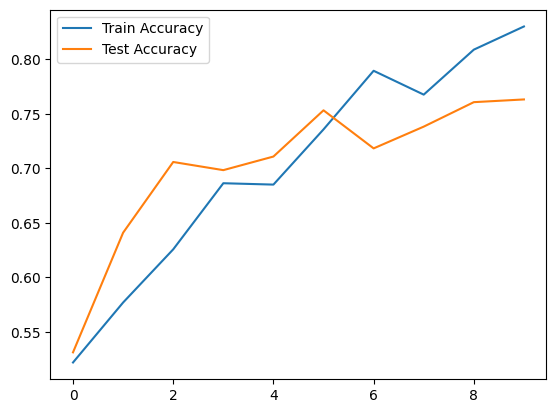

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Test Accuracy")
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

preds = model.predict(test_it)
pred_labels = (preds > 0.5).astype(int)
true_labels = test_it.classes

print(confusion_matrix(true_labels, pred_labels))
print(classification_report(true_labels, pred_labels))


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step
[[145  55]
 [ 40 161]]
              precision    recall  f1-score   support

           0       0.78      0.72      0.75       200
           1       0.75      0.80      0.77       201

    accuracy                           0.76       401
   macro avg       0.76      0.76      0.76       401
weighted avg       0.76      0.76      0.76       401

